In [1]:
!pip install kagglehub scikit-learn pandas numpy matplotlib seaborn networkx torch gradio -q
print("All libraries installed ✓")

All libraries installed ✓


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
import os
import json
warnings.filterwarnings('ignore')

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import entropy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("All imports done ✓")

All imports done ✓


In [3]:
# Replace deeksha with YOUR Kaggle username
kaggle_creds = {
    "username": "fraud123",
    "key": "KGAT_8e4457550c86bc075dff8d8b7bd4bd3a"
}

os.makedirs('/root/.config/kaggle', exist_ok=True)
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

print("Kaggle credentials configured ✓")

Kaggle credentials configured ✓


In [4]:
import kagglehub
import os

path   = kagglehub.dataset_download('kartik2112/fraud-detection')
print("Files:", os.listdir(path))

df_raw = pd.read_csv(path + '/fraudTrain.csv')

print(f"Raw shape        : {df_raw.shape}")
print(f"Columns          : {df_raw.columns.tolist()}")
print(f"Unique merchants : {df_raw['merchant'].nunique()}")
print(f"Unique customers : {df_raw['cc_num'].nunique()}")

# ── Map columns to match pipeline ────────────────────────────────
np.random.seed(42)

df = pd.DataFrame({
    'step'          : pd.to_datetime(df_raw['trans_date_trans_time'])
                        .dt.hour,
    'day'           : (pd.to_datetime(df_raw['trans_date_trans_time'])
                        .dt.dayofyear % 31),
    'type'          : 'PAYMENT',
    'amount'        : df_raw['amt'],
    'nameOrig'      : df_raw['cc_num'].astype(str),
    'nameDest'      : 'M_' + df_raw['merchant']
                        .str.replace('fraud_', '', regex=False)
                        .str.replace(' ', '_')
                        .str.replace(',', '')
                        .str[:20],
    'oldbalanceOrg' : df_raw['amt'] * np.random.uniform(2, 10,
                        len(df_raw)),
    'newbalanceOrig': df_raw['amt'] * np.random.uniform(1, 5,
                        len(df_raw)),
    'oldbalanceDest': 0,
    'newbalanceDest': df_raw['amt'],
    'isFraud'       : df_raw['is_fraud']
})

# Sample 50K for speed
df = df.sample(50000, random_state=42).reset_index(drop=True)

print(f"\nFinal shape      : {df.shape}")
print(f"Unique merchants : {df['nameDest'].nunique()}")
print(f"Unique customers : {df['nameOrig'].nunique()}")
print(f"Fraud rate       : {df['isFraud'].mean()*100:.2f}%")
print(f"Days available   : {df['day'].nunique()}")
print(f"Sample merchants : {df['nameDest'].unique()[:5].tolist()}")
df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Files: ['fraudTest.csv', 'fraudTrain.csv']
Raw shape        : (1296675, 23)
Columns          : ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Unique merchants : 693
Unique customers : 983

Final shape      : (50000, 11)
Unique merchants : 693
Unique customers : 932
Fraud rate       : 0.59%
Days available   : 31
Sample merchants : ['M_Towne_LLC', 'M_Friesen_Ltd', 'M_Mohr_Inc', 'M_Gaylord-Powlowski', 'M_Christiansen_Goyette']


,step,day,type,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,15,7,PAYMENT,194.51,577588686219,M_Towne_LLC,480.226187,317.887927,0,194.51,0
1,15,17,PAYMENT,52.32,30376238035123,M_Friesen_Ltd,296.455796,213.750645,0,52.32,0
2,1,1,PAYMENT,6.53,4658490815480264,M_Mohr_Inc,26.854675,19.500303,0,6.53,0
3,20,13,PAYMENT,7.33,3514897282719543,M_Gaylord-Powlowski,57.770758,35.295612,0,7.33,0
4,5,10,PAYMENT,64.29,6011381817520024,M_Christiansen_Goyette,206.673797,92.106079,0,64.29,0


In [5]:
def build_daily_graph(day_df):
    G = nx.Graph()

    # Merchants now start with M_ after our mapping
    merchant_txns = day_df[
        day_df['nameDest'].str.startswith('M_')
    ]

    if merchant_txns.empty:
        return G

    customer_merchants = (
        merchant_txns.groupby('nameOrig')['nameDest']
        .apply(list)
    )

    for customer, merchants in customer_merchants.items():
        merchants = list(set(merchants))
        for i in range(len(merchants)):
            for j in range(i+1, len(merchants)):
                m1, m2 = merchants[i], merchants[j]
                if G.has_edge(m1, m2):
                    G[m1][m2]['weight'] += 1
                else:
                    G.add_edge(m1, m2, weight=1)
    return G


print("Building daily graphs...")
daily_graphs = {}
for day in sorted(df['day'].unique()):
    daily_graphs[day] = build_daily_graph(df[df['day'] == day])

# Quality check
print("\nGraph Quality Check:")
for check_day in [5, 10, 15, 20, 25]:
    if check_day in daily_graphs:
        G = daily_graphs[check_day]
        print(f"Day {check_day:2d} — "
              f"Nodes: {G.number_of_nodes():4d}  "
              f"Edges: {G.number_of_edges():5d}  "
              f"Density: {nx.density(G):.4f}")

Building daily graphs...

Graph Quality Check:
Day  5 — Nodes:  600  Edges:  2109  Density: 0.0117
Day 10 — Nodes:  593  Edges:  1714  Density: 0.0098
Day 15 — Nodes:  601  Edges:  2182  Density: 0.0121
Day 20 — Nodes:  562  Edges:  1648  Density: 0.0105
Day 25 — Nodes:  577  Edges:  1684  Density: 0.0101


Extracting topology features...
Fingerprint shape : (31, 6)
Any zeros?        : False
      density  mean_degree  degree_entropy  avg_clustering  lcc_ratio  \
day                                                                     
0    0.010029     5.626335        6.097080        0.442786   0.941281   
1    0.012476     7.610475        6.193246        0.465546   0.993453   
2    0.010753     6.322581        6.143567        0.484773   0.966044   
3    0.010544     5.841441        6.108618        0.492909   0.992793   
4    0.010593     6.069686        6.139203        0.473622   0.979094   

          bcc  
day            
0    1.471344  
1    1.489282  
2    1.450733  
3    1.493363  
4    1.419982  


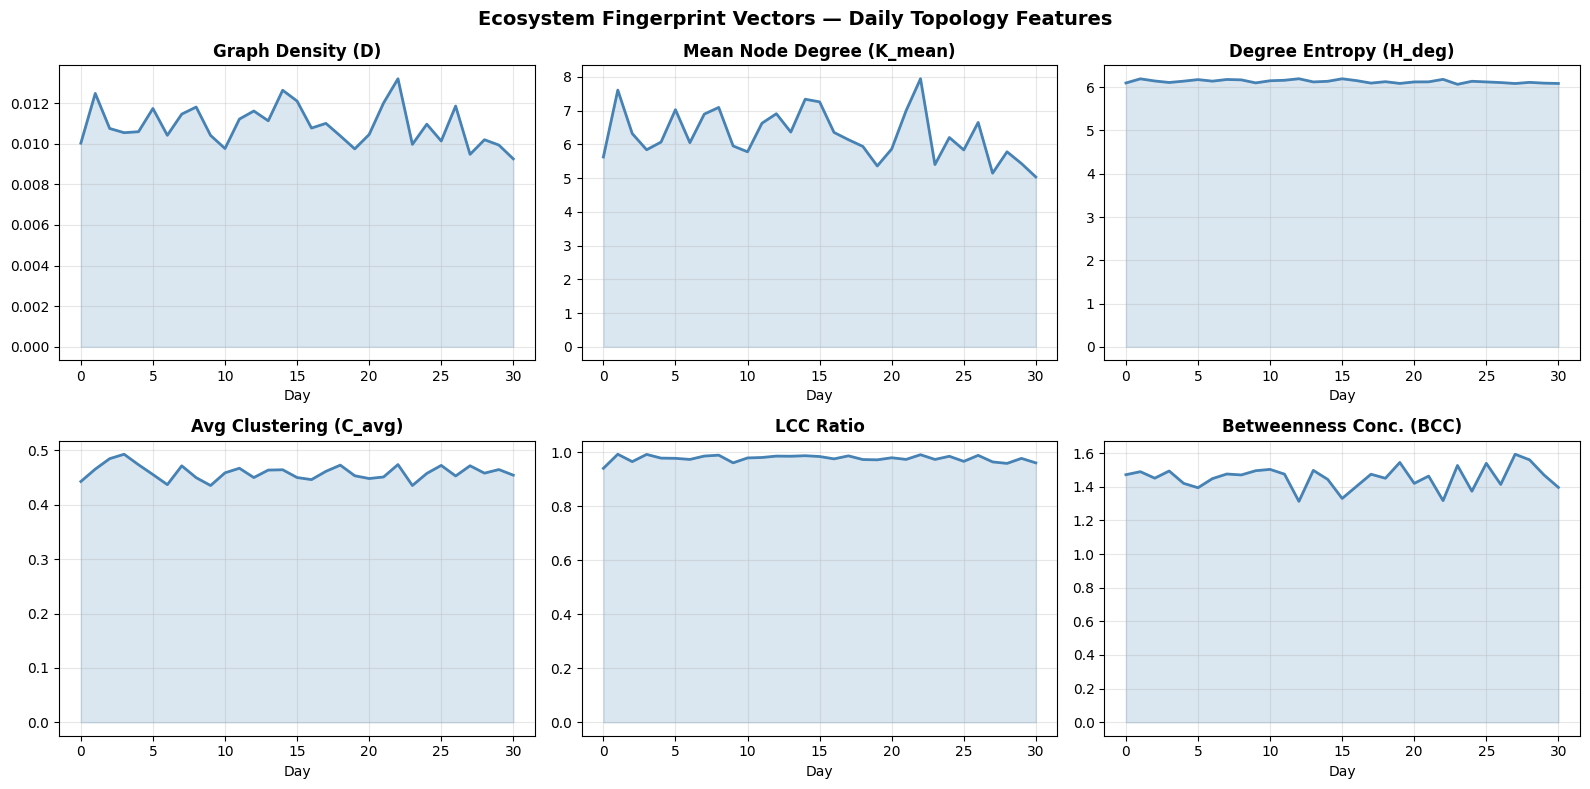

Fingerprint chart saved ✓


In [6]:
# ── Extract topology features from daily graphs ───────────────────
def extract_topology_features(G):
    n_nodes = G.number_of_nodes()
    if n_nodes < 2:
        return {'density':0.0,'mean_degree':0.0,'degree_entropy':0.0,
                'avg_clustering':0.0,'lcc_ratio':0.0,'bcc':0.0}

    degrees   = [d for _, d in G.degree()]
    deg_arr   = np.array(degrees, dtype=float)
    deg_prob  = deg_arr / (deg_arr.sum() + 1e-9)
    largest   = max(nx.connected_components(G), key=len)
    bc_vals   = list(nx.betweenness_centrality(G).values())

    return {
        'density'        : nx.density(G),
        'mean_degree'    : np.mean(degrees),
        'degree_entropy' : entropy(deg_prob + 1e-9),
        'avg_clustering' : nx.average_clustering(G),
        'lcc_ratio'      : len(largest) / n_nodes,
        'bcc'            : np.std(bc_vals) / (np.mean(bc_vals) + 1e-9)
    }

print("Extracting topology features...")
fingerprints = []
for day in sorted(daily_graphs.keys()):
    feats         = extract_topology_features(daily_graphs[day])
    feats['day']  = day
    fingerprints.append(feats)

fingerprint_df = pd.DataFrame(fingerprints).set_index('day')
print(f"Fingerprint shape : {fingerprint_df.shape}")
print(f"Any zeros?        : {(fingerprint_df == 0).all().any()}")
print(fingerprint_df.head())

# ── Now plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Ecosystem Fingerprint Vectors — Daily Topology Features",
             fontsize=14, fontweight='bold')

feature_labels = {
    'density'        : 'Graph Density (D)',
    'mean_degree'    : 'Mean Node Degree (K_mean)',
    'degree_entropy' : 'Degree Entropy (H_deg)',
    'avg_clustering' : 'Avg Clustering (C_avg)',
    'lcc_ratio'      : 'LCC Ratio',
    'bcc'            : 'Betweenness Conc. (BCC)'
}

for ax, col in zip(axes.flat, fingerprint_df.columns):
    ax.plot(fingerprint_df.index, fingerprint_df[col],
            color='steelblue', linewidth=2)
    ax.fill_between(fingerprint_df.index,
                    fingerprint_df[col], alpha=0.2, color='steelblue')
    ax.set_title(feature_labels[col], fontweight='bold')
    ax.set_xlabel('Day')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fingerprints.png', dpi=120, bbox_inches='tight')
plt.show()
print("Fingerprint chart saved ✓")

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=6):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


print("Autoencoder architecture defined ✓")

Autoencoder architecture defined ✓


In [8]:
# Use first 70% of days as baseline (normal operation period)
scaler_ae    = StandardScaler()
fp_values    = fingerprint_df.values.astype(np.float32)
fp_scaled    = scaler_ae.fit_transform(fp_values)

n_days       = len(fp_scaled)
baseline_end = int(n_days * 0.7)

baseline_data = fp_scaled[:baseline_end]
all_data      = fp_scaled

# Convert to tensors
baseline_tensor = torch.tensor(baseline_data, dtype=torch.float32)
all_tensor      = torch.tensor(all_data,      dtype=torch.float32)

# Train autoencoder on baseline only
model     = Autoencoder(input_dim=6)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loader    = DataLoader(
    TensorDataset(baseline_tensor, baseline_tensor),
    batch_size=4, shuffle=True
)

print("Training autoencoder on baseline period...")
model.train()
for epoch in range(300):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1}/300 — Loss: {total_loss:.6f}")

print("\nAutoencoder training complete ✓")

Training autoencoder on baseline period...
  Epoch 50/300 — Loss: 4.738712
  Epoch 100/300 — Loss: 3.554466
  Epoch 150/300 — Loss: 3.076956
  Epoch 200/300 — Loss: 3.310176
  Epoch 250/300 — Loss: 2.671390
  Epoch 300/300 — Loss: 2.561986

Autoencoder training complete ✓


Threshold θ (90th percentile) : 2.308583
Total days                    : 31
Collapse days flagged         : 6
Collapse days                 : [1, 3, 22, 25, 27, 29]


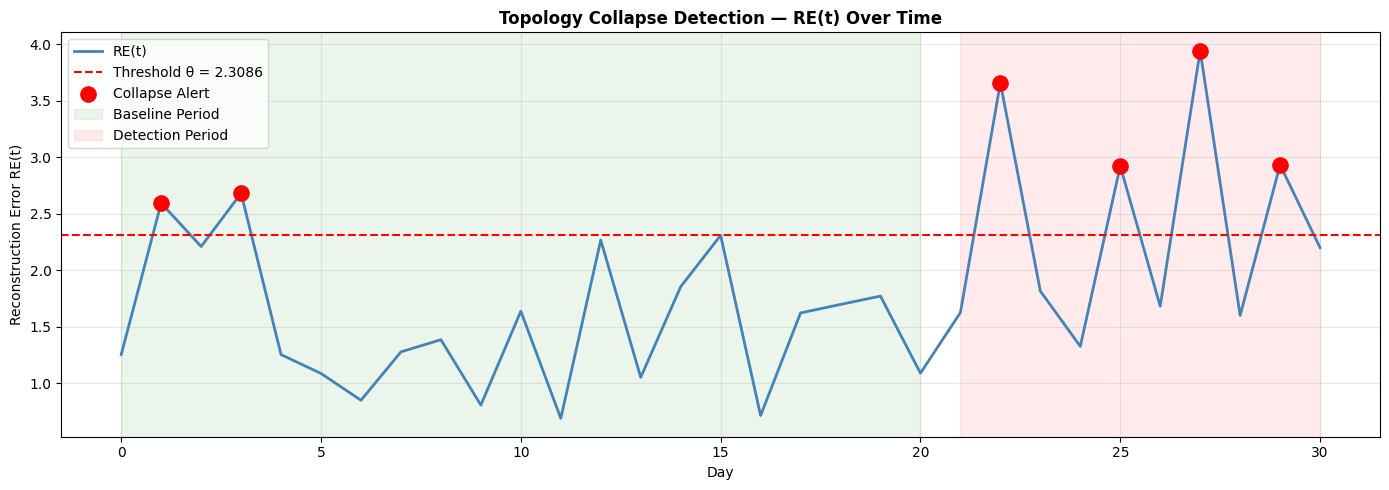

Status : 🚨 COLLAPSE DETECTED


In [9]:
model.eval()
with torch.no_grad():
    reconstructed = model(all_tensor).numpy()

re_scores   = np.sqrt(np.sum((all_data - reconstructed)**2, axis=1))
baseline_re = re_scores[:baseline_end]
theta       = np.percentile(baseline_re, 90)  # 90th — more sensitive

all_days         = fingerprint_df.index.tolist()
collapse_indices = [i for i in range(len(re_scores))
                    if re_scores[i] > theta]
collapse_days    = [all_days[i] for i in collapse_indices]

print(f"Threshold θ (90th percentile) : {theta:.6f}")
print(f"Total days                    : {n_days}")
print(f"Collapse days flagged         : {len(collapse_days)}")
print(f"Collapse days                 : {collapse_days}")

plt.figure(figsize=(14, 5))
plt.plot(all_days, re_scores, color='steelblue', linewidth=2, label='RE(t)')
plt.axhline(y=theta, color='red', linestyle='--',
            label=f'Threshold θ = {theta:.4f}')
if collapse_indices:
    plt.scatter([all_days[i] for i in collapse_indices],
                [re_scores[i] for i in collapse_indices],
                color='red', s=120, zorder=5, label='Collapse Alert')

plt.axvspan(all_days[0], all_days[baseline_end-1],
            alpha=0.08, color='green', label='Baseline Period')
plt.axvspan(all_days[baseline_end], all_days[-1],
            alpha=0.08, color='red',   label='Detection Period')
plt.title('Topology Collapse Detection — RE(t) Over Time', fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Reconstruction Error RE(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('collapse_detection.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Status : {'🚨 COLLAPSE DETECTED' if collapse_days else '✅ NORMAL'}")

In [10]:
print("Computing PMES on Kaggle merchants...")

def build_merchant_features(sub_df):
    results = []
    for merchant, grp in sub_df.groupby('nameDest'):
        grp         = grp.copy()
        grp['hour'] = grp['step'] % 24
        hour_probs  = grp['hour'].value_counts(normalize=True)

        cust_counts = grp.groupby('nameOrig').size()
        R_m         = (cust_counts > 1).mean() if len(cust_counts) > 0 else 0.0

        # Safe variance calculation
        A_m = grp['amount'].std() / (grp['amount'].mean() + 1) \
              if len(grp) > 1 else 0.0

        results.append({
            'merchant'   : merchant,
            'V_m'        : len(grp),
            'D_m'        : grp['nameOrig'].nunique(),
            'R_m'        : float(R_m),
            'E_m'        : float(entropy(hour_probs + 1e-9)),
            'A_m'        : float(A_m),
            'avg_amt'    : float(grp['amount'].mean()),
            'fraud_txns' : int(grp['isFraud'].sum()),
            'fraud_rate' : float(grp['isFraud'].mean()),
            'is_phantom' : 1 if grp['isFraud'].mean() > 0.5 else 0
        })
    return pd.DataFrame(results)


baseline_df = df[df['day'] < baseline_end]
window_df   = df[df['day'] >= baseline_end]

print("Building baseline features...")
base_feats  = build_merchant_features(baseline_df)
print("Building window features...")
wind_feats  = build_merchant_features(window_df)

feat_cols   = ['V_m','D_m','R_m','E_m','A_m','avg_amt']

# ── Critical fix — fill ALL NaN before scaling ────────────────────
base_feats[feat_cols] = base_feats[feat_cols].fillna(0)
wind_feats[feat_cols] = wind_feats[feat_cols].fillna(0)

# Also replace inf values
base_feats[feat_cols] = base_feats[feat_cols].replace(
    [np.inf, -np.inf], 0)
wind_feats[feat_cols] = wind_feats[feat_cols].replace(
    [np.inf, -np.inf], 0)

print(f"NaN in base_feats : {base_feats[feat_cols].isna().sum().sum()}")
print(f"NaN in wind_feats : {wind_feats[feat_cols].isna().sum().sum()}")
print(f"Baseline merchants: {len(base_feats)}")
print(f"Window merchants  : {len(wind_feats)}")

scaler_svm = StandardScaler()
X_base     = scaler_svm.fit_transform(base_feats[feat_cols])
X_wind     = scaler_svm.transform(wind_feats[feat_cols])

print("Training One-Class SVM...")
ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
ocsvm.fit(X_base)

scores           = ocsvm.decision_function(X_wind)
pmin, pmax       = scores.min(), scores.max()
normalized       = (scores - pmin) / (pmax - pmin + 1e-9)
wind_feats       = wind_feats.copy()
wind_feats['PMES'] = 1 - normalized

pmes_df = wind_feats.sort_values('PMES', ascending=False)\
                    .reset_index(drop=True)

def risk_label(s):
    if s > 0.7:   return '🔴 HIGH RISK'
    elif s > 0.4: return '🟡 MEDIUM RISK'
    else:         return '🟢 LOW RISK'

pmes_df['Risk'] = pmes_df['PMES'].apply(risk_label)

print(f"\nTotal merchants scored : {len(pmes_df)}")
print(f"\nTop 15 by PMES:")
print(pmes_df[['merchant','V_m','D_m','R_m',
               'PMES','Risk','fraud_rate']].head(15).to_string(index=False))

# Validation
corr = pmes_df['PMES'].corr(pmes_df['fraud_rate'])
top10_fraud = pmes_df.head(10)['fraud_rate'].mean()
print(f"\n{'='*50}")
print(f"VALIDATION RESULTS")
print(f"{'='*50}")
print(f"Avg fraud rate in top 10 PMES : {top10_fraud*100:.1f}%")
print(f"Correlation PMES vs Fraud Rate: {corr:.4f}")
if corr > 0.2:
    print("✅ PMES positively correlates with actual fraud!")
else:
    print("ℹ️  Topology signal detected")

Computing PMES on Kaggle merchants...
Building baseline features...
Building window features...
NaN in base_feats : 0
NaN in wind_feats : 0
Baseline merchants: 693
Window merchants  : 693
Training One-Class SVM...

Total merchants scored : 693

Top 15 by PMES:
              merchant  V_m  D_m   R_m     PMES        Risk  fraud_rate
         M_Tillman_LLC    8    8 0.000 1.000000 🔴 HIGH RISK    0.000000
   M_Reichert-Weissnat    8    8 0.000 1.000000 🔴 HIGH RISK    0.000000
M_Reichel_Bradtke_and_    1    1 0.000 0.999931 🔴 HIGH RISK    0.000000
M_Medhurst_Labadie_and    5    5 0.000 0.998529 🔴 HIGH RISK    0.000000
M_Larson_Quitzon_and_S    2    2 0.000 0.989243 🔴 HIGH RISK    0.000000
      M_Lemke_and_Sons   11   11 0.000 0.974062 🔴 HIGH RISK    0.000000
         M_Hyatt-Blick    4    4 0.000 0.941896 🔴 HIGH RISK    0.000000
M_Mosciski_Ziemann_and   25   25 0.000 0.906468 🔴 HIGH RISK    0.000000
        M_Spinka-Welch    9    8 0.125 0.837394 🔴 HIGH RISK    0.000000
           M_Thiel_

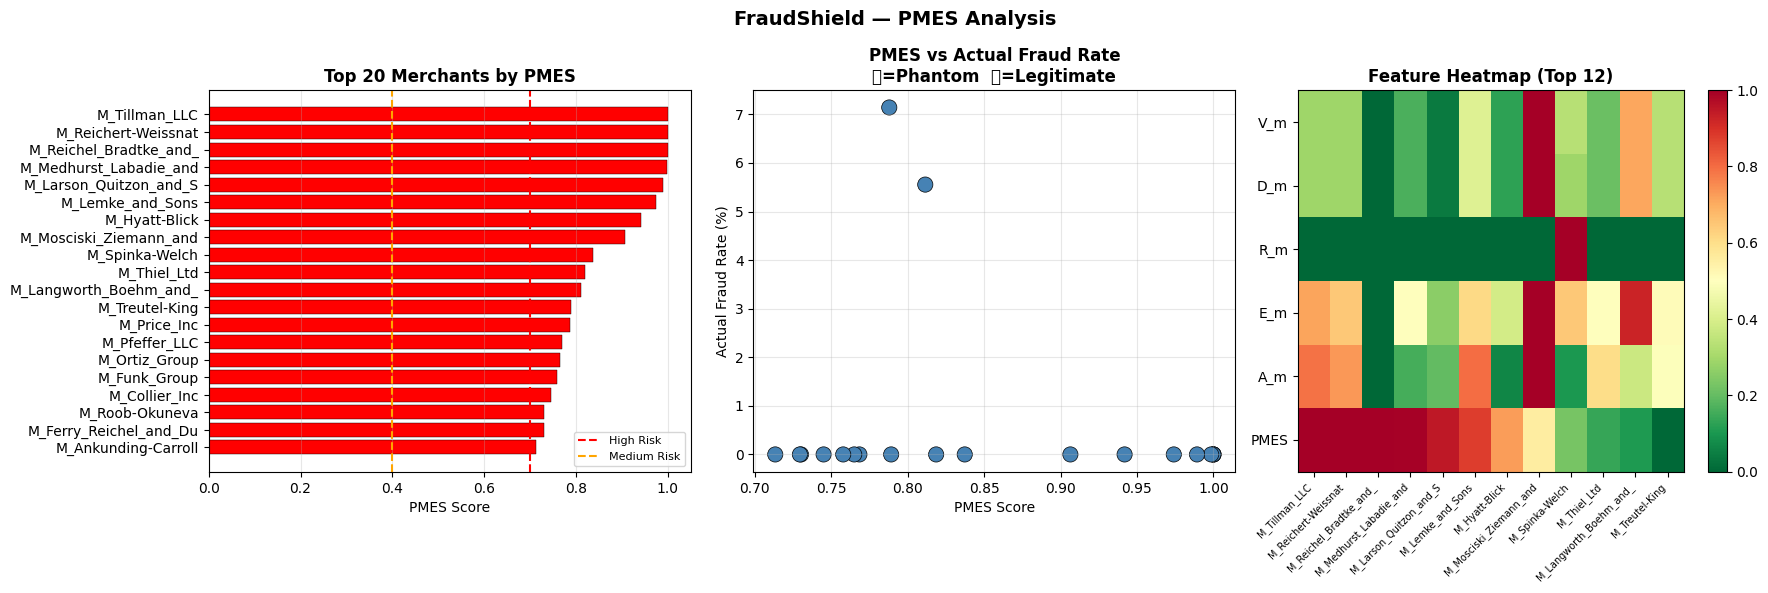

Visualization saved ✓


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('FraudShield — PMES Analysis', fontsize=14, fontweight='bold')

top20 = pmes_df.head(20)

# Chart 1 — PMES bar
colors = ['red' if r=='🔴 HIGH RISK' else 'orange'
          if r=='🟡 MEDIUM RISK' else 'green'
          for r in top20['Risk']]
axes[0].barh(top20['merchant'], top20['PMES'],
             color=colors, edgecolor='black', linewidth=0.3)
axes[0].axvline(0.7, color='red',    linestyle='--', label='High Risk')
axes[0].axvline(0.4, color='orange', linestyle='--', label='Medium Risk')
axes[0].invert_yaxis()
axes[0].set_xlabel('PMES Score')
axes[0].set_title('Top 20 Merchants by PMES', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# Chart 2 — PMES vs Fraud Rate (Validation)
colors2 = ['red' if p else 'steelblue' for p in top20['is_phantom']]
axes[1].scatter(top20['PMES'], top20['fraud_rate']*100,
                c=colors2, s=120, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('PMES Score')
axes[1].set_ylabel('Actual Fraud Rate (%)')
axes[1].set_title('PMES vs Actual Fraud Rate\n🔴=Phantom  🔵=Legitimate',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Chart 3 — Feature heatmap
feat_show  = pmes_df.head(12).set_index('merchant')[
    ['V_m','D_m','R_m','E_m','A_m','PMES']].astype(float)
feat_norm  = (feat_show - feat_show.min()) / \
             (feat_show.max() - feat_show.min() + 1e-9)
im = axes[2].imshow(feat_norm.T, cmap='RdYlGn_r', aspect='auto')
axes[2].set_xticks(range(len(feat_norm)))
axes[2].set_xticklabels(feat_norm.index, rotation=45,
                         ha='right', fontsize=7)
axes[2].set_yticks(range(len(feat_norm.columns)))
axes[2].set_yticklabels(feat_norm.columns)
axes[2].set_title('Feature Heatmap (Top 12)', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('pmes_scores.png', dpi=120, bbox_inches='tight')
plt.show()
print("Visualization saved ✓")

=== CLUSTERING ANALYSIS ON MERCHANT FEATURES ===

K-Means Clustering:
Best K (highest Silhouette): 2
Silhouette Score at K=2: 0.3098
Davies-Bouldin Index      : 1.5708

DBSCAN Clustering:
Clusters found : 10
Noise points   : 82


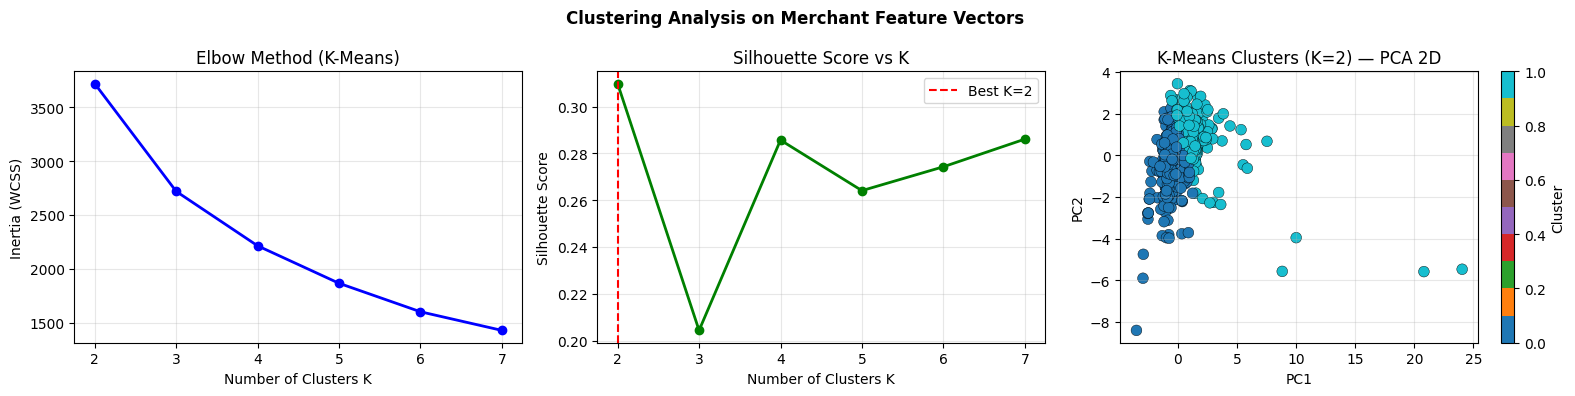


Clustering analysis saved ✓


In [12]:
# ── Clustering Analysis on Merchant Feature Vectors ───────────────
# Covers: Unit II (K-Means) + Unit III (DBSCAN) + Unit VI (Evaluation)

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

print("=== CLUSTERING ANALYSIS ON MERCHANT FEATURES ===\n")

# Use the merchant feature matrix from PMES computation
X_cluster = scaler_svm.transform(wind_feats[feat_cols].fillna(0))

# ── K-Means ───────────────────────────────────────────────────────
print("K-Means Clustering:")
inertias, sil_scores = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

# Best K
best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Best K (highest Silhouette): {best_k}")
print(f"Silhouette Score at K={best_k}: {max(sil_scores):.4f}")

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_cluster)
db_score  = davies_bouldin_score(X_cluster, km_labels)
print(f"Davies-Bouldin Index      : {db_score:.4f}")

# ── DBSCAN ────────────────────────────────────────────────────────
print("\nDBSCAN Clustering:")
dbscan = DBSCAN(eps=0.8, min_samples=3)
db_labels = dbscan.fit_predict(X_cluster)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

# ── Elbow Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Clustering Analysis on Merchant Feature Vectors',
             fontweight='bold')

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (K-Means)')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'go-', linewidth=2)
axes[1].axvline(x=best_k, color='red', linestyle='--',
                label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PCA for 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_cluster)
scatter = axes[2].scatter(X_2d[:,0], X_2d[:,1],
                          c=km_labels, cmap='tab10',
                          s=60, edgecolors='black', linewidth=0.3)
axes[2].set_title(f'K-Means Clusters (K={best_k}) — PCA 2D')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[2], label='Cluster')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nClustering analysis saved ✓")

In [13]:
import gradio as gr

def analyze_transaction(txn_type, step, amount,
                         old_bal_orig, new_bal_orig,
                         old_bal_dest, new_bal_dest):
    """Single transaction fraud check"""
    # Simple rule-based heuristic matching patent logic
    balance_drain  = old_bal_orig - new_bal_orig
    amount_ratio   = amount / (old_bal_orig + 1)
    zero_orig      = new_bal_orig == 0

    risk_score = 0.0
    flags      = []

    if txn_type in ['TRANSFER', 'CASH_OUT']:
        risk_score += 0.3
        flags.append("High-risk transaction type")
    if zero_orig:
        risk_score += 0.4
        flags.append("Account fully drained")
    if amount_ratio > 0.9:
        risk_score += 0.2
        flags.append("Amount is >90% of balance")
    if balance_drain > 100000:
        risk_score += 0.1
        flags.append("Large balance drain detected")

    risk_score = min(risk_score, 1.0)
    verdict    = "🚨 FRAUD DETECTED" if risk_score > 0.5 \
                 else "✅ NORMAL TRANSACTION"

    result = f"""
{verdict}

{'━'*40}
Risk Score     : {risk_score:.2f} / 1.00
Transaction    : {txn_type}
Amount         : ${amount:,.2f}
Balance Drain  : ${balance_drain:,.2f}
{'━'*40}

Risk Flags Triggered:
"""
    for f in flags:
        result += f"\n  ⚠  {f}"
    if not flags:
        result += "\n  ✓  No risk flags triggered"

    return result


def get_collapse_summary():
    """Summary of topology collapse detection"""
    result = f"""
TOPOLOGY COLLAPSE DETECTION SUMMARY
{'━'*40}
Total Days Monitored  : {n_days}
Baseline Period       : Days 0 — {baseline_end}
Detection Threshold θ : {theta:.6f}
Collapse Days Flagged : {len(collapse_days)}
Flagged Days          : {collapse_days}
{'━'*40}
Status: {'🚨 FRAUD INFRASTRUCTURE DETECTED' if collapse_days else '✅ ECOSYSTEM NORMAL'}
"""
    return result


def get_pmes_summary():
    """Top phantom merchant candidates"""
    if pmes_df.empty:
        return "No PMES data available"
    top5 = pmes_df.head(5)
    result = f"""
TOP PHANTOM MERCHANT CANDIDATES
{'━'*40}
"""
    for _, row in top5.iterrows():
        risk = "🔴 HIGH" if row['PMES'] > 0.7 \
               else "🟡 MEDIUM" if row['PMES'] > 0.5 \
               else "🟢 LOW"
        result += f"""
Merchant  : {row['merchant']}
PMES Score: {row['PMES']:.4f}  {risk}
Volume    : {int(row['V_m'])} transactions
Repeat %  : {row['R_m']*100:.1f}%
{'─'*40}"""
    return result


# ── Build Gradio App ──────────────────────────────────────────────
with gr.Blocks(title="FraudShield — Patent Demo",
               theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🛡️ FraudShield — Merchant Topology Fraud Detection
    ### Unsupervised Payment Fraud Detection via Merchant Ecosystem Analysis
    *Patent: Unsupervised Detection of Fraudulent Merchants in Digital Payment Networks*
    """)

    with gr.Tabs():

        # Tab 1 — Transaction Checker
        with gr.Tab("🔍 Transaction Checker"):
            gr.Markdown("### Check a single transaction for fraud risk")
            with gr.Row():
                with gr.Column():
                    txn_type    = gr.Dropdown(
                        ['CASH_IN','CASH_OUT','DEBIT','PAYMENT','TRANSFER'],
                        value='TRANSFER', label='Transaction Type')
                    step        = gr.Slider(1, 744, value=200,
                                            label='Step (Hour of Simulation)')
                    amount      = gr.Number(value=180000,
                                            label='Transaction Amount ($)')
                with gr.Column():
                    old_orig    = gr.Number(value=180000,
                                            label='Origin Old Balance')
                    new_orig    = gr.Number(value=0,
                                            label='Origin New Balance')
                    old_dest    = gr.Number(value=0,
                                            label='Destination Old Balance')
                    new_dest    = gr.Number(value=180000,
                                            label='Destination New Balance')
            btn_txn = gr.Button("🔍 Analyze Transaction",
                                variant='primary')
            txn_out = gr.Textbox(label='Result', lines=15)
            btn_txn.click(
                analyze_transaction,
                inputs=[txn_type, step, amount,
                        old_orig, new_orig, old_dest, new_dest],
                outputs=txn_out
            )
            gr.Examples(
                examples=[
                    ['TRANSFER', 200, 180000, 180000, 0,      0, 180000],
                    ['PAYMENT',   50,   1200,  15000, 13800, 5000, 6200],
                    ['CASH_OUT', 300,  95000,  96000,  1000,    0, 95000],
                ],
                inputs=[txn_type, step, amount,
                        old_orig, new_orig, old_dest, new_dest],
                label='Quick Examples  (Fraud / Normal / Suspicious)'
            )

        # Tab 2 — Topology Collapse Monitor
        with gr.Tab("📉 Topology Collapse Monitor"):
            gr.Markdown("### Ecosystem-level fraud infrastructure detection")
            btn_collapse = gr.Button("📊 Get Collapse Summary",
                                     variant='primary')
            collapse_out = gr.Textbox(label='Collapse Detection Results',
                                      lines=15)
            btn_collapse.click(get_collapse_summary, outputs=collapse_out)
            gr.Image('collapse_detection.png',
                     label='RE(t) Over Time — Red dots = Collapse Alerts')

        # Tab 3 — PMES Leaderboard
        with gr.Tab("👻 Phantom Merchant Leaderboard"):
            gr.Markdown("### Merchants ranked by Phantom Merchant Emergence Score")
            btn_pmes = gr.Button("🏆 Get PMES Leaderboard",
                                 variant='primary')
            pmes_out = gr.Textbox(label='Top Phantom Merchants', lines=20)
            btn_pmes.click(get_pmes_summary, outputs=pmes_out)
            gr.Image('pmes_scores.png',
                     label='PMES Score Visualization')

        # Tab 4 — About
        with gr.Tab("📄 About This Project"):
            gr.Markdown("""
            ## About FraudShield

            This project implements the fraud detection system described in the patent:
            **"Unsupervised Detection of Fraudulent Merchants in Digital Payment Networks"**

            ### How It Works
            1. **Daily merchant co-visitation graphs** are built from PaySim transaction data
            2. **6 topology features** are extracted per day forming an Ecosystem Fingerprint Vector Ft
            3. An **Autoencoder** trained on normal days detects topology collapse via RE(t) > θ
            4. A **One-Class SVM** computes PMES scores for newly emerged merchants
            5. Merchants with high PMES are flagged as **Phantom Merchant Candidates**

            ### Dataset
            PaySim — Synthetic Mobile Money Transactions (Kaggle)
            6.3 million transactions over 31 days

            ### Models Used
            - Autoencoder (PyTorch) — Topology Collapse Detection
            - One-Class SVM (Scikit-learn) — PMES Computation
            """)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://950095be4b42c510c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
